In [83]:
import pandas as pd
import matplotlib.pyplot as plt
import json

## 1. Data loading
At the beginning from json I get a player oriented dataframe which later will be transformed into dataframe where one row == one match statistics.


In [18]:
with open('data/competition_train.json') as f:
    train_json = json.load(f)


In [77]:

players = []
match_meta_columns = [
    'tier', 'radiant_win', 'duration', 'pre_game_duration', 'start_time',
    'tower_status_radiant', 'tower_status_dire', 'barracks_status_radiant',
    'barracks_status_dire', 'first_blood_time', 'human_players', 'leagueid',
    'game_mode','radiant_score', 'dire_score'

]
for match_id, match in enumerate(train_json):
    for p in match['players']:
        row = p.copy()

        for col in match_meta_columns:
            row[col] = match.get(col)

        row['match_id'] = match_id
        players.append(row)



players_df = pd.DataFrame(players)

benchmarks_df = pd.json_normalize(players_df['benchmarks'])

players_df = pd.concat(
    [players_df.drop(columns=['benchmarks']), benchmarks_df],
    axis=1
)
num_cols = players_df.select_dtypes(include=["number"]).columns
str_cols = players_df.select_dtypes(include=["string", "object"]).columns

players_df[num_cols] = players_df[num_cols].fillna(0)
players_df[str_cols] = players_df[str_cols].fillna("")


Index(['leaver_status', 'aghanims_scepter', 'aghanims_shard', 'moonshard',
       'ability_upgrades_arr', 'total_gold', 'total_xp', 'kills_per_min',
       'abandons', 'account_id',
       ...
       'xp_per_min.pct', 'kills_per_min.raw', 'kills_per_min.pct',
       'last_hits_per_min.raw', 'last_hits_per_min.pct',
       'hero_damage_per_min.raw', 'hero_damage_per_min.pct',
       'hero_healing_per_min.raw', 'hero_healing_per_min.pct',
       'tower_damage.pct'],
      dtype='str', length=115)

## 2. Data aggregation

In [87]:


team_stats = {
    "economy": ["gold", "gold_spent", "net_worth", "gold_per_min", "xp_per_min"],
    "combat": ["kills", "deaths", "assists", "hero_damage", "tower_damage", "hero_healing", "kills_per_min", "kda"],
    "farm": ["last_hits", "denies", "last_hits_per_min"]
}

def aggregate_team(df_team, prefix):
    agg_dict = {}
    for group, cols in team_stats.items():
        for col in cols:
            if col in df_team.columns:
                agg_dict[f"{prefix}_{col}_sum"] = df_team[col].sum()
                agg_dict[f"{prefix}_{col}_mean"] = df_team[col].mean()
    return agg_dict

def match_features(df_players):
    radiant_df = df_players[df_players['isRadiant'] == True]
    dire_df = df_players[df_players['isRadiant'] == False]

    radiant_stats = aggregate_team(radiant_df, "radiant")
    dire_stats = aggregate_team(dire_df, "dire")

    diff_stats = {}
    for key in radiant_stats.keys():
        base_key = key.replace("radiant_", "")
        dire_key = key.replace("radiant_", "dire_")
        if dire_key in dire_stats:
            diff_stats[f"diff_{base_key}"] = radiant_stats[key] - dire_stats[dire_key]

    meta_cols = ['tier', 'radiant_win', 'duration', 'pre_game_duration', 'start_time',
                 'tower_status_radiant', 'tower_status_dire', 'barracks_status_radiant',
                 'barracks_status_dire', 'first_blood_time', 'human_players', 'leagueid',
                 'game_mode','radiant_score', 'dire_score']

    meta = df_players.iloc[0][meta_cols].to_dict()
    match_row = {**radiant_stats, **dire_stats, **diff_stats, **meta}
    return pd.DataFrame([match_row])


final_rows = []
for match_id, df_match in players_df.groupby('match_id'):
    final_rows.append(match_features(df_match))

final_df = pd.concat(final_rows, ignore_index=True)

In [79]:
final_df.head()

,radiant_gold_sum,radiant_gold_mean,radiant_gold_spent_sum,radiant_gold_spent_mean,radiant_net_worth_sum,radiant_net_worth_mean,radiant_gold_per_min_sum,radiant_gold_per_min_mean,radiant_xp_per_min_sum,radiant_xp_per_min_mean,...,tower_status_radiant,tower_status_dire,barracks_status_radiant,barracks_status_dire,first_blood_time,human_players,leagueid,game_mode,radiant_score,dire_score
0,9137,1827.4,124630,24926.0,121007,24201.4,5204,1040.8,8920,1784.0,...,1958,0,63,3,108,10,0,23,34,17
1,22697,4539.4,114925,22985.0,131142,26228.4,6055,1211.0,11833,2366.6,...,1952,6,61,51,39,10,0,23,34,27
2,7707,1541.4,142850,28570.0,136917,27383.4,2770,554.0,4220,844.0,...,0,1828,0,63,173,10,0,22,36,56
3,16165,3233.0,76335,15267.0,87245,17449.0,2886,577.2,3964,792.8,...,1983,0,63,0,105,10,0,22,54,23
4,10618,2123.6,65225,13045.0,69378,13875.6,2653,530.6,3029,605.8,...,2039,0,63,0,48,10,0,22,40,23


## 3. Data exploration

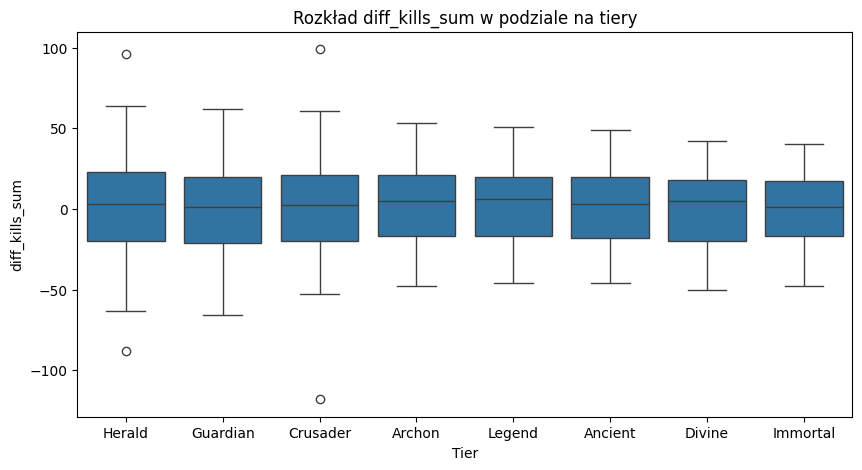

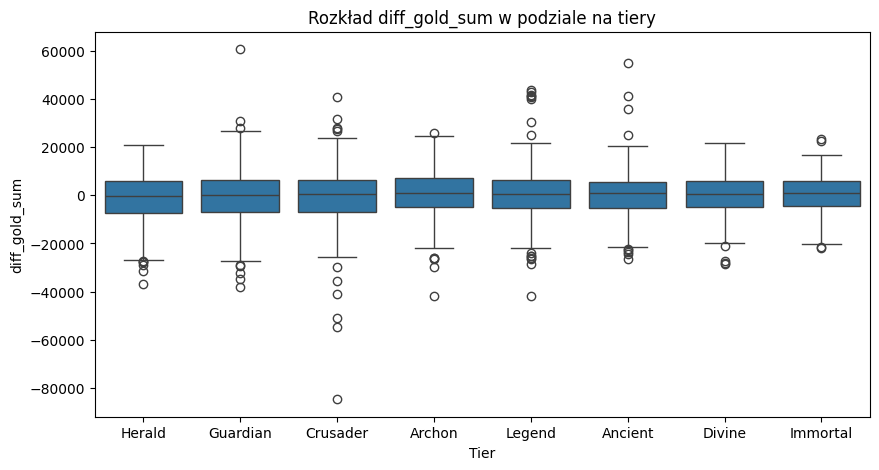

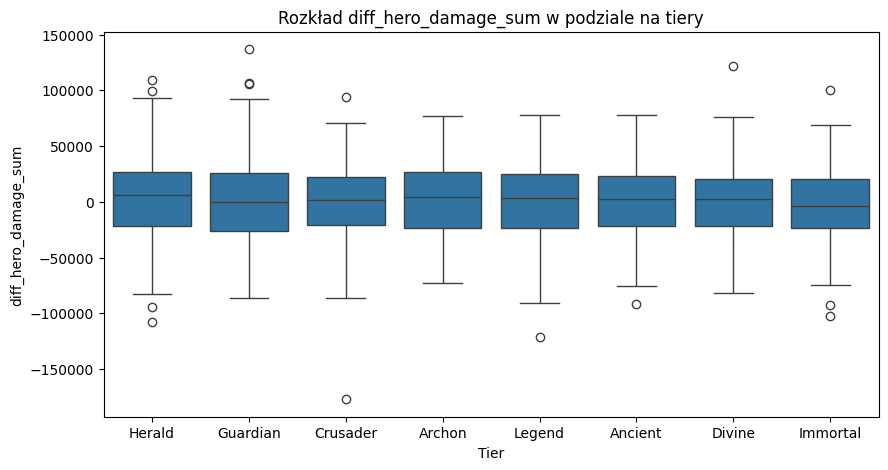

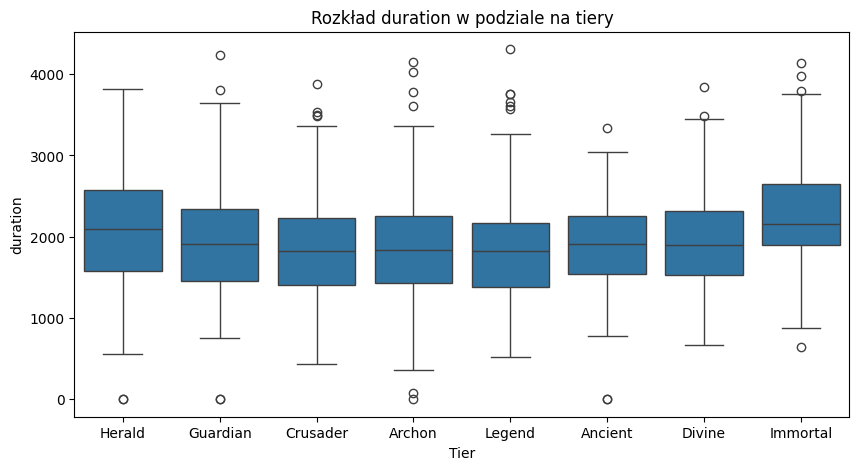

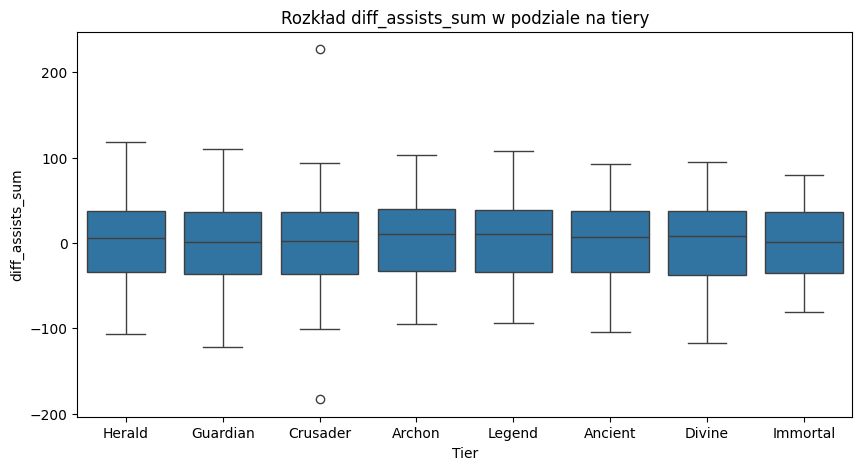

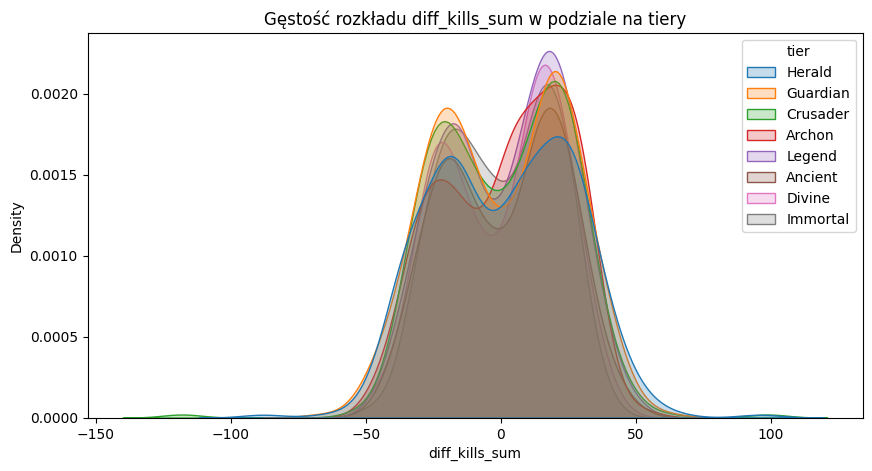

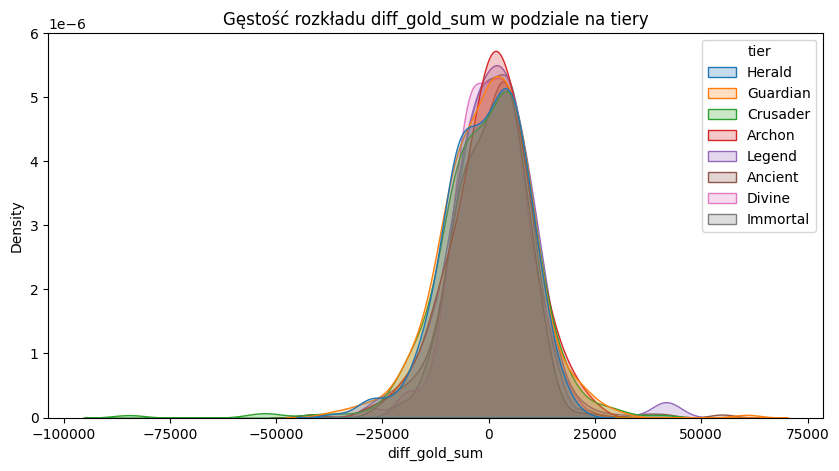

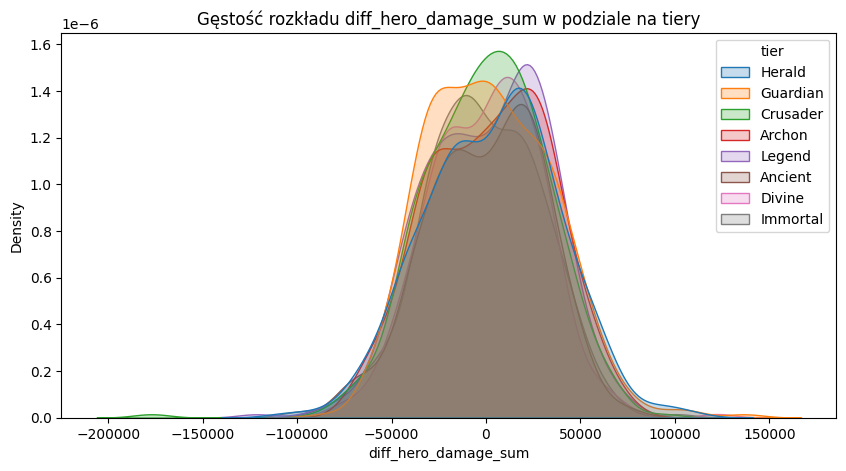

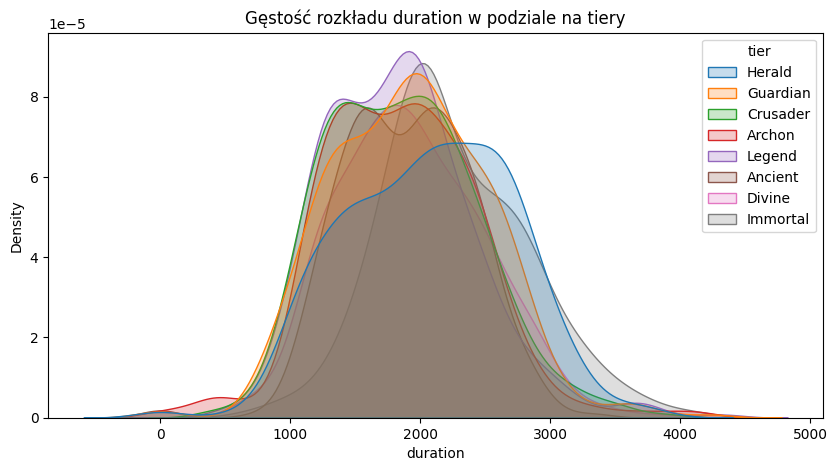

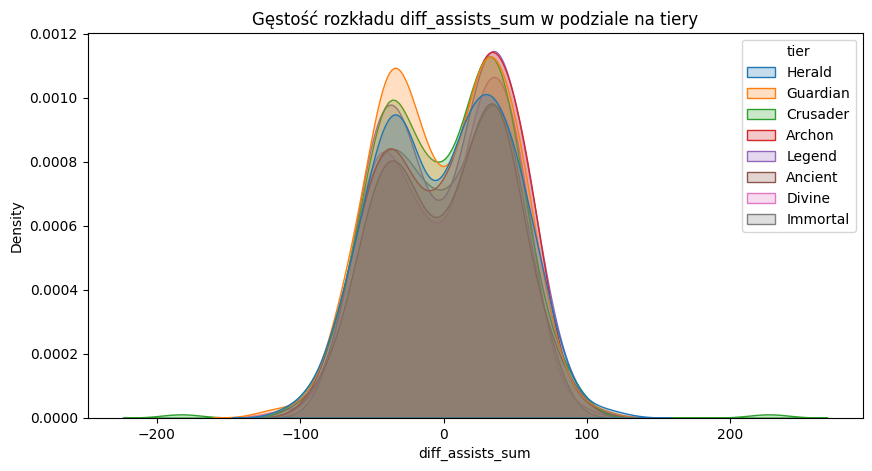

In [93]:
import matplotlib.pyplot as plt
import seaborn as sns

tier_order = [
    'Herald', 'Guardian', 'Crusader', 'Archon',
    'Legend', 'Ancient', 'Divine', 'Immortal'
]

final_df['tier'] = pd.Categorical(final_df['tier'], categories=tier_order, ordered=True)

features = ['diff_kills_sum', 'diff_gold_sum', 'diff_hero_damage_sum', 'duration', 'diff_assists_sum']

for feature in features:
    plt.figure(figsize=(10,5))
    sns.boxplot(x='tier', y=feature, data=final_df, order=tier_order)
    plt.title(f'Rozkład {feature} w podziale na tiery')
    plt.ylabel(feature)
    plt.xlabel('Tier')
    plt.show()


for feature in features:
    plt.figure(figsize=(10,5))
    sns.kdeplot(data=final_df, x=feature, hue='tier', fill=True)
    plt.title(f'Gęstość rozkładu {feature} w podziale na tiery')
    plt.xlabel(feature)
    plt.show()